In [1]:
import numpy as np
import scipy.sparse
import scipy.sparse.linalg
import os
import xarray as xr
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm

/home/gabriela/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/gabriela/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
os.chdir('/mnt/storage0/jmarson/ANALYSES/MASKS')

data = xr.open_dataset('ANHA4_mesh_zgr.nc')

lon = data.variables['nav_lon']
lat = data.variables['nav_lat'] 

e1v = data.variables['e1v']
e2u = data.variables['e2u']
e3t = data.variables['e3t_0']

dx = e1v[0]
dy = e2u[0]
e3t = e3t[0]
e3t = np.copy(e3t)
dx = np.copy(dx)
dy = np.copy(dy)

os.chdir('/mnt/storage0/jmarson/NEMO/ANHA4/ANHA4-EJM009-S')

da = xr.open_dataset('ANHA4-EJM009_y2002m01d05_gridT.nc')

deptht = da.variables['deptht']

In [3]:
os.chdir('/mnt/storage0/gabriela/ANALYSES/SCRIPTS/data_from_scripts')

vs = np.load('ANHA4-EJM010-S_TimeSeries_STRF_20071_201712.npz')
vs = vs['ConvE']

vd = np.load('ANHA4-EJM012-S_TimeSeries_STRF_20071_201712.npz')
vd = vd['ConvE']

In [4]:
avg_vd = np.nanmean(vd, axis = 0)
avg_vs = np.nanmean(vs, axis = 0)

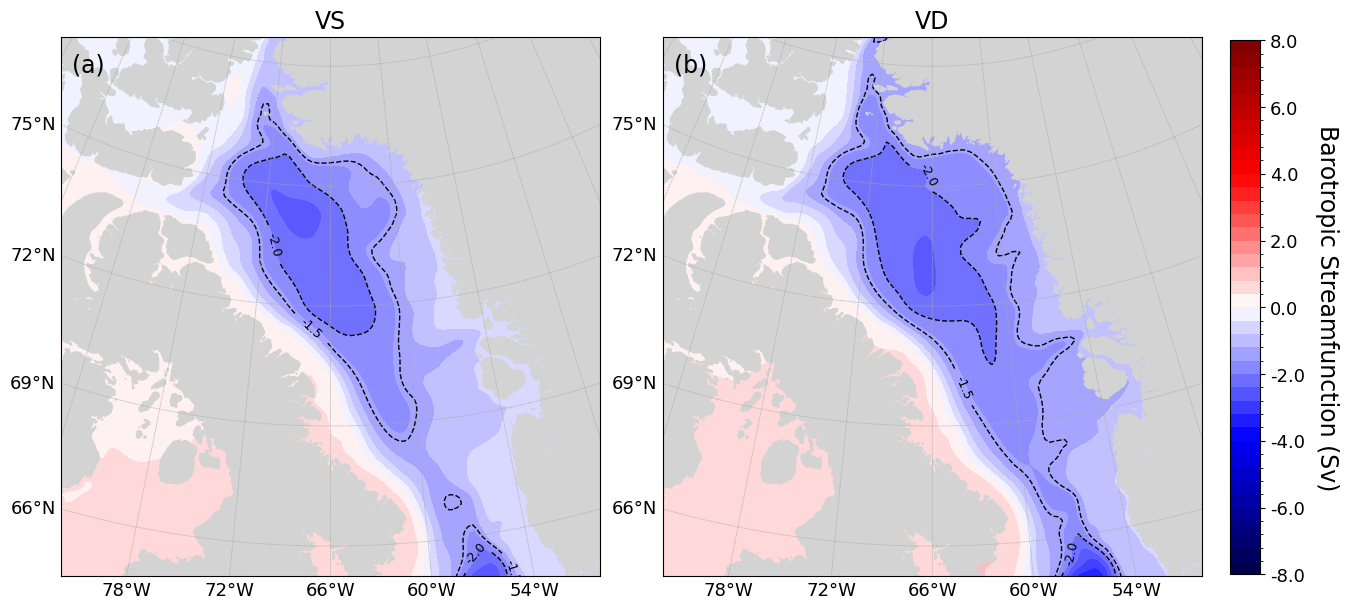

In [51]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.basemap import Basemap
from matplotlib.colors import BoundaryNorm
import numpy as np

# 🗺️ Plot config
vmin = -8
vmax = 8
levels = 40
lv = (vmax - vmin) / levels
levels = np.arange(vmin, vmax + lv, lv)
cmap = plt.get_cmap('seismic')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# 🎯 Dataset dictionary: can be raw values or precomputed differences
data_dict = {'VS': avg_vs,  'VD': avg_vd}

fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

for ax, (name, data) in zip(axs, data_dict.items()):
    ax.set_title(name, fontsize=17)

    
    m = Basemap(projection='stere',
            width=1.5e6,     # 1,500,000 meters (~1500 km)
            height=1.5e6,    # 1,500,000 meters (~1500 km)
            lat_0=72,        # center latitude near Baffin Bay
            lon_0=-66, resolution = 'f',       # center longitude near Baffin Bay
            ax=ax)

    # Grid coords – make sure lon/lat are 2D with shape matching your data
    x, y = lon[1:799, 1:543], lat[1:799, 1:543]  # Adjust as needed
    m.contourf(x, y, data, latlon=True, levels=levels, vmin=vmin, vmax=vmax, cmap=cmap)
    cs = m.contour(x, y, data, latlon=True, levels=[ -2, -1.5], colors='black', linewidths=1.0)
    plt.clabel(cs, fmt='%1.1f', fontsize=9)

    m.drawcoastlines(color='lightgray')
    m.fillcontinents(color='lightgray', lake_color='lightgray')
    m.drawmeridians(np.arange(0, 360, 6), labels=[0, 0, 0, 1], linewidth=0.6, color='darkgray', fontsize=13)
    m.drawparallels(np.arange(-90, 90, 3), labels=[1, 0, 0, 0], linewidth=0.6, color='darkgray', fontsize=13)

# 🎚️ Shared colorbar
cax = fig.add_axes([1.02, 0.05, 0.025, 0.89])
cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label('Barotropic Streamfunction (Sv)', rotation=270, labelpad=25, fontsize = 17)

ticks = np.arange(vmin, vmax + 0.01, 2)
cb.set_ticks(ticks)
cb.set_ticklabels([f"{t:.1f}" for t in ticks])
cb.ax.tick_params(labelsize=13)  

labels = ['a', 'b']

for i, ax in enumerate(axs):
    # Add corner label in the upper-left corner of each subplot
    ax.text(0.02, 0.97, f'({labels[i]})', transform=ax.transAxes,
            fontsize=17, va='top', ha='left')
    
figure_title = 'BSTF_BaffinBay_VDandVS'
os.chdir('/mnt/storage0/gabriela/ANALYSES/FIGS/figs_paper')
plt.savefig(figure_title + '.png', dpi=300, bbox_inches='tight')
plt.show()

plt.show()


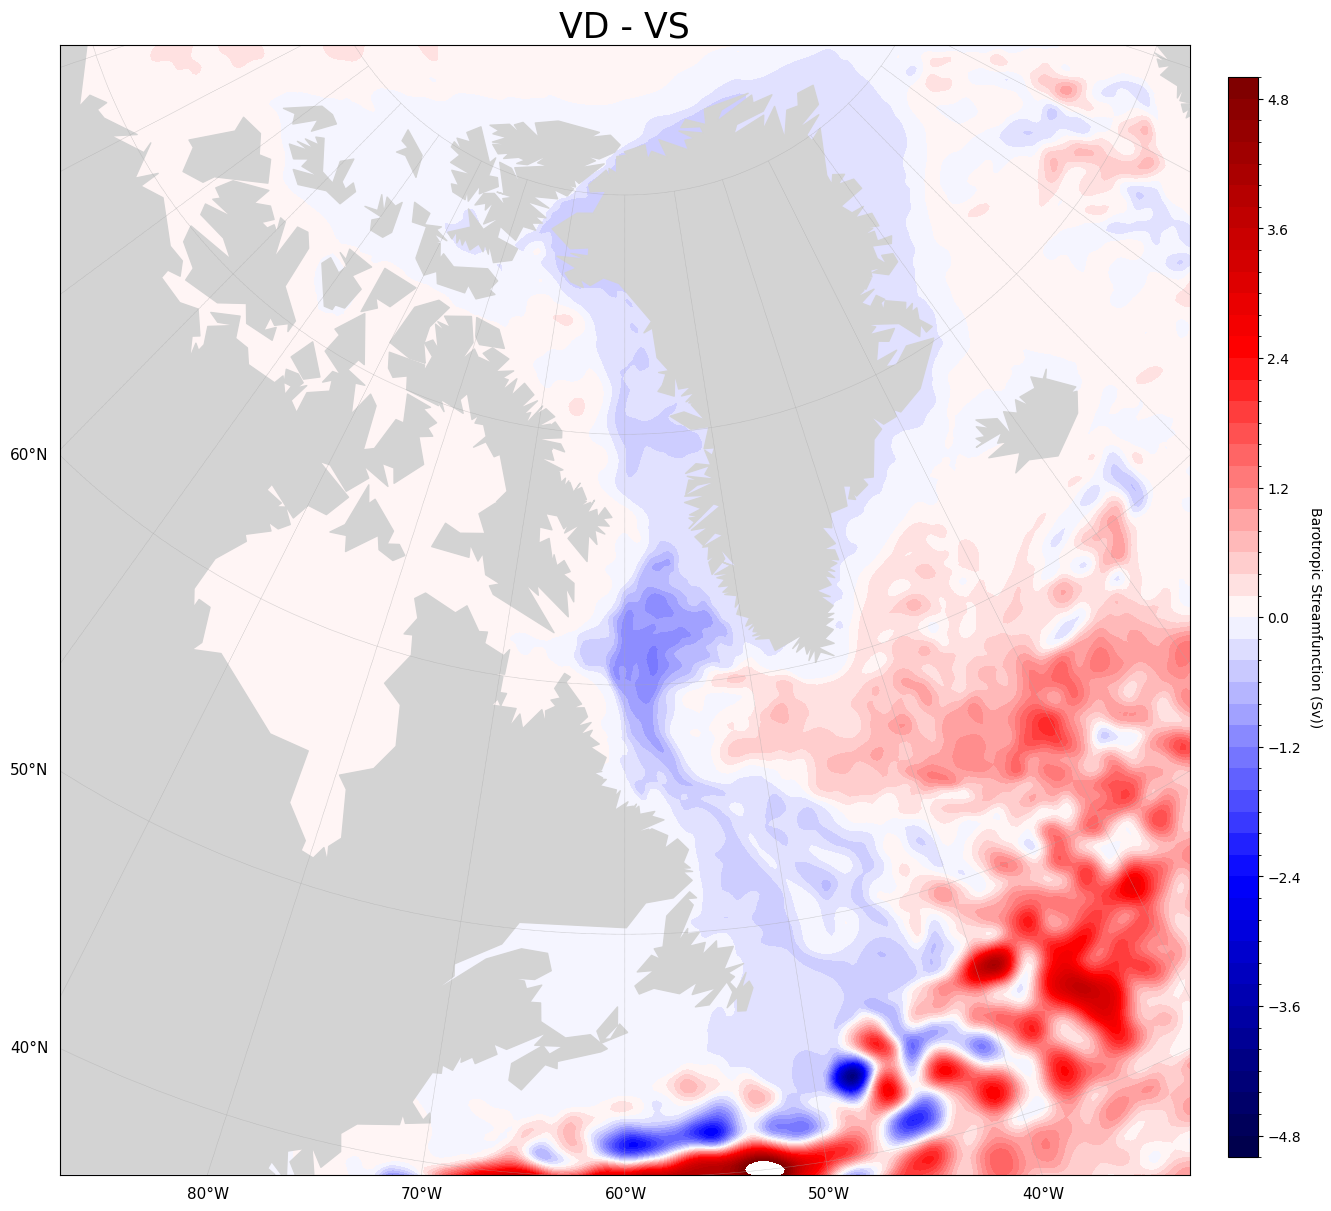

In [24]:
fig, ax = plt.subplots(figsize=(12, 12), constrained_layout=True)

vmin = -5
vmax = 5
levels = 50
lv = (vmax - vmin)/levels
levels = list(np.arange(vmin, vmax+lv, lv))
cmap = plt.get_cmap('seismic')

data = avg_vd - avg_vs # Assumindo que essa variável já existe
title = 'VD - VS'

ax.set_title(title, fontsize=25)
m = Basemap(projection='aea', resolution='c', width=5E6, height=5E6, lat_0=63, lon_0=-60, ax=ax)
m.contourf(lon[1:799,1:543], lat[1:799,1:543], data, latlon=True, levels=levels, vmin=vmin, vmax=vmax, cmap=cmap)

#m.contour(lon, lat, ss[0], latlon=True, levels=[-9, -4], colors = 'black', 
#              linestyles = 'dashed', linewidths = 1.2)


m.drawcoastlines(color='lightgray')
m.fillcontinents(color='lightgray', lake_color='lightgray')
m.drawmeridians(np.arange(0,360,10), labels=[0, 0, 0, 1], linewidth=0.4, color='darkgray', fontsize=11)
m.drawparallels(np.arange(-90,90,10), labels=[1, 0, 0, 0], linewidth=0.4, color='darkgray', fontsize=11)

# Colorbar
cax = fig.add_axes([1.02, 0.04, 0.025, 0.9])
lv = np.linspace(vmin, vmax, len(levels))
norm = BoundaryNorm(lv, ncolors=cmap.N, clip=True)  # Use cmap.N to get the number of colors
cb1 = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, orientation='vertical')
cb1.ax.set_ylabel('Barotropic Streamfunction (Sv))', rotation=270, labelpad=15)
cb1.ax.ticklabel_format(style='sci', scilimits=(-1,4), axis='both')

# Title for the entire figure

plt.show()